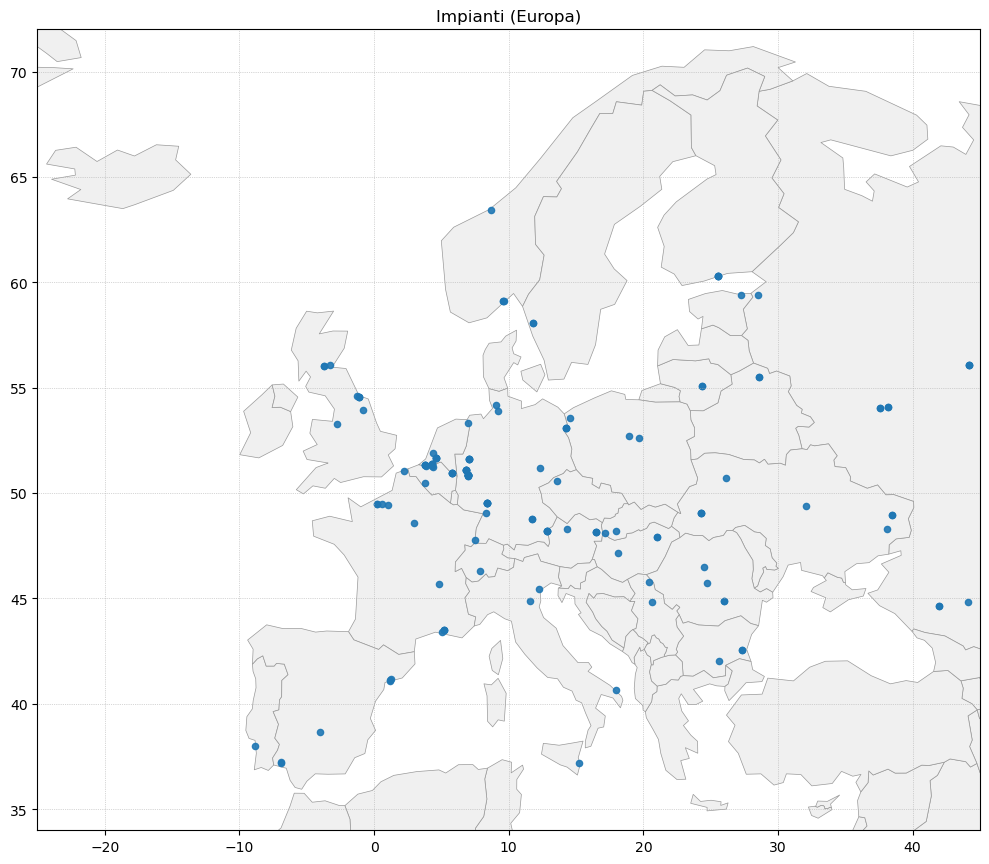

In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

# --- dati ---
plants = pd.read_excel("SFI_ALD_Petrochemicals_Sample_EU_NA_Apr_2022.xlsx",
                       sheet_name="SFI_ALD_Petrochemicals_EUNA")
europe = plants[plants['region'] == 'Europe'].dropna(subset=['latitude','longitude']).copy()

gdf = gpd.GeoDataFrame(
    europe,
    geometry=gpd.points_from_xy(europe['longitude'], europe['latitude']),
    crs="EPSG:4326"
)

# --- base map: Natural Earth via URL (S3 mirror) ---
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

# bounding box Europa approx (lon_min, lat_min, lon_max, lat_max)
bbox = (-25, 34, 45, 72)
world_eu = world.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]
gdf_eu   = gdf.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

# --- plot ---
fig, ax = plt.subplots(figsize=(10, 10))
world_eu.plot(ax=ax, color="#f0f0f0", edgecolor="#999999", linewidth=0.5)
gdf_eu.plot(ax=ax, markersize=20, alpha=0.9)
ax.set_title("Impianti (Europa)")
ax.set_xlim(bbox[0], bbox[2]); ax.set_ylim(bbox[1], bbox[3])
ax.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.show()


In [3]:
# Filter data on European plants for column 'country' == 'Netherlands', 'Belgium', 'Luxembourg' or 'Germany'
selected_countries = ['Netherlands', 'Belgium', 'Luxembourg', 'Germany']

# keep selected countries, and for Germany require state == 'North Rhine-Westphalia'
mask_countries = europe['country'].isin(selected_countries)
mask_germany_nrw = (europe['country'] == 'Germany') & (europe['state'] == 'North Rhine-Westphalia')
mask = mask_countries & ((europe['country'] != 'Germany') | mask_germany_nrw)
europe_filtered = europe[mask].copy()

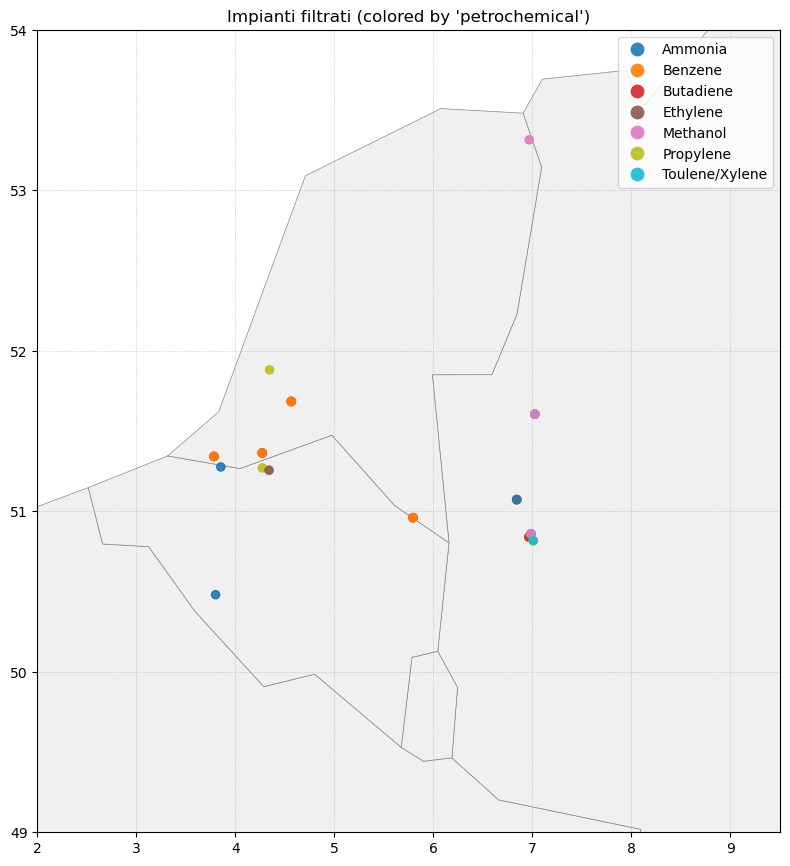

In [4]:
# pip install geopandas shapely matplotlib
import geopandas as gpd
import matplotlib.pyplot as plt

# Assumo europe_filtered già creato
df = europe_filtered.dropna(subset=["latitude","longitude"]).copy()
df["petrochemical"] = df["petrochemical"].fillna("Unknown").astype("category")

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"
)

# Base map Natural Earth
world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

# ROI: Benelux + NRW (lon_min, lat_min, lon_max, lat_max)
bbox = (2.0, 49.0, 9.5, 54.0)
world_roi = world.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]
gdf_roi   = gdf.cx[bbox[0]:bbox[2], bbox[1]:bbox[3]]

fig, ax = plt.subplots(figsize=(8, 9))
world_roi.plot(ax=ax, color="#f0f0f0", edgecolor="#888888", linewidth=0.5)

# colore per categoria: usa direttamente la colonna
gdf_roi.plot(
    ax=ax,
    column="petrochemical",
    categorical=True,
    legend=True,
    markersize=35,
    alpha=0.9
)

ax.set_title("Impianti filtrati (colored by 'petrochemical')", fontsize=12)
ax.set_xlim(bbox[0], bbox[2]); ax.set_ylim(bbox[1], bbox[3])
ax.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout(); plt.show()



In [5]:
# Filter columns that we need
europe_filtered = europe_filtered[[
    'uid', 'latitude', 'longitude',
    'petrochemical', 'capacity'
]]
# add column 'altitude' with value 0 for all rows
europe_filtered['altitude'] = 0

In [6]:
# Save df to csv
europe_filtered.to_csv("europe_filtered_plants.csv", index=False)